<a href="https://colab.research.google.com/github/khodiboev/computer_vision/blob/main/menu-detector/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/khodiboev/computer_vision/blob/main/menu-detector/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Menu Detector — Food Image Classifier (MobileNetV2 Transfer Learning)

Classifies a food photo into **5 classes**: `hamburger`, `hot_dog`, `dessert` (chocolate cake + cheesecake), `kebab`, `pizza`.

**Pipeline**
1. Data: Food-101 subsets + web-scraped kebab images (cleaned with CLIP zero-shot filtering, see `data_scraping.ipynb`)
2. Preprocessing: copy to local disk, convert to RGB JPEG, cap dessert sources to balance classes
3. Stratified 80/20 train/validation split (fixed seed)
4. Training: ImageNet-pretrained MobileNetV2, data augmentation, class-weighted loss for the minority `kebab` class
5. Evaluation: per-epoch validation, best checkpoint by balanced accuracy, confusion matrix, per-class report, prediction gallery

Runtime: **Runtime → Change runtime type → T4 GPU**

In [1]:
# ----------------------------
# Imports & Google Drive
# ----------------------------
import os
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ----------------------------
# Configuration
# ----------------------------
SEED = 42

DRIVE_ROOT = '/content/drive/MyDrive/Colab Notebooks'
DATASET_PATH = f'{DRIVE_ROOT}/food101_dataset'
MODEL_PATH = f'{DRIVE_ROOT}/menu_detector.pth'
RESULTS_DIR = f'{DRIVE_ROOT}/menu_detector_results'
LOCAL_DATA = '/content/data'

# target class -> source folders in the dataset
CLASS_SOURCES = {
    'hamburger': ['hamburger'],
    'hot_dog': ['hot_dog'],
    'dessert': ['chocolate_cake', 'cheesecake'],  # class consolidation
    'kebab': ['kebab'],
    'pizza': ['pizza'],
}
# cap merged sources so 'dessert' is not 2x larger than the others
MAX_PER_SOURCE = {'chocolate_cake': 500, 'cheesecake': 500}

CLASSES = list(CLASS_SOURCES.keys())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp')
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
VAL_RATIO = 0.2
LR_BACKBONE = 1e-4
LR_HEAD = 1e-3


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print('device:', device)
print('classes:', CLASS_TO_IDX)

device: cuda
classes: {'hamburger': 0, 'hot_dog': 1, 'dessert': 2, 'kebab': 3, 'pizza': 4}


In [3]:
# ----------------------------
# Preprocess: Drive -> local disk (RGB JPEG, short side 256)
# Reading from local disk is much faster than Drive during training,
# and converting here removes broken / RGBA / webp issues once.
# ----------------------------
def prepare_local_copy(src_path, dst_path, short_side=256):
    if os.path.exists(dst_path):
        return True
    try:
        with Image.open(src_path) as img:
            img = img.convert('RGB')
            w, h = img.size
            scale = short_side / min(w, h)
            if scale < 1:
                img = img.resize((round(w * scale), round(h * scale)), Image.BILINEAR)
            img.save(dst_path, 'JPEG', quality=92)
        return True
    except Exception as e:
        print(f'Skipping broken image: {src_path} ({e})')
        return False


records = []
for cls, sources in CLASS_SOURCES.items():
    for src in sources:
        src_dir = os.path.join(DATASET_PATH, src)
        files = sorted(f for f in os.listdir(src_dir) if f.lower().endswith(IMG_EXTS))
        limit = MAX_PER_SOURCE.get(src)
        if limit and len(files) > limit:
            files = sorted(random.Random(SEED).sample(files, limit))

        dst_dir = os.path.join(LOCAL_DATA, src)
        os.makedirs(dst_dir, exist_ok=True)
        for f in files:
            dst = os.path.join(dst_dir, os.path.splitext(f)[0] + '.jpg')
            if prepare_local_copy(os.path.join(src_dir, f), dst):
                records.append({'path': dst, 'source': src, 'class': cls, 'label': CLASS_TO_IDX[cls]})

df = pd.DataFrame(records)
print('Total images:', len(df))
print(df.groupby(['class', 'source']).size())

Total images: 4113
class      source        
dessert    cheesecake         500
           chocolate_cake     500
hamburger  hamburger         1000
hot_dog    hot_dog           1000
kebab      kebab              113
pizza      pizza             1000
dtype: int64


In [4]:
# ----------------------------
# Stratified train / validation split
# ----------------------------
train_df, val_df = train_test_split(
    df, test_size=VAL_RATIO, stratify=df['label'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    'train': train_df['class'].value_counts(),
    'val': val_df['class'].value_counts(),
}).reindex(CLASSES)
split_summary['total'] = split_summary.sum(axis=1)
print(split_summary)

           train  val  total
class                       
hamburger    800  200   1000
hot_dog      800  200   1000
dessert      800  200   1000
kebab         90   23    113
pizza        800  200   1000


In [5]:
# ----------------------------
# Transforms (augmentation only for training)
# ----------------------------
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


# ----------------------------
# Custom Dataset
# ----------------------------
class FoodDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths = frame['path'].tolist()
        self.labels = frame['label'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(image), self.labels[idx]


train_loader = DataLoader(FoodDataset(train_df, train_transform), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(FoodDataset(val_df, eval_transform), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
print('train batches:', len(train_loader), '| val batches:', len(val_loader))

train batches: 103 | val batches: 26


In [6]:
# ----------------------------
# Model: pretrained MobileNetV2 + new classifier head
# ----------------------------
model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

# Class weights: rare classes (kebab) get a larger weight in the loss
counts = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(len(train_df) / (NUM_CLASSES * counts), dtype=torch.float32)
print('class weights:', dict(zip(CLASSES, class_weights.numpy().round(2))))

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Smaller learning rate for the pretrained backbone, larger for the new head
optimizer = optim.Adam([
    {'params': model.features.parameters(), 'lr': LR_BACKBONE},
    {'params': model.classifier.parameters(), 'lr': LR_HEAD},
])

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 129MB/s]


class weights: {'hamburger': np.float32(0.82), 'hot_dog': np.float32(0.82), 'dessert': np.float32(0.82), 'kebab': np.float32(7.31), 'pizza': np.float32(0.82)}


In [7]:
# ----------------------------
# Training loop (validation every epoch, keep best by balanced accuracy)
# ----------------------------
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * labels.size(0)
            all_preds.extend(outputs.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return total_loss / len(all_labels), np.array(all_labels), np.array(all_preds)


history = []
best_bal_acc, best_epoch, best_state = 0.0, 0, None

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss, correct, seen = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        seen += labels.size(0)

    val_loss, y_true, y_pred = evaluate(model, val_loader)
    row = {
        'epoch': epoch,
        'train_loss': running_loss / seen,
        'train_acc': correct / seen,
        'val_loss': val_loss,
        'val_acc': accuracy_score(y_true, y_pred),
        'val_bal_acc': balanced_accuracy_score(y_true, y_pred),
    }
    history.append(row)

    marker = ''
    if row['val_bal_acc'] > best_bal_acc:
        best_bal_acc, best_epoch = row['val_bal_acc'], epoch
        best_state = copy.deepcopy(model.state_dict())
        marker = '  <- best'
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | train loss {row['train_loss']:.4f} acc {row['train_acc']:.2%} | "
          f"val loss {row['val_loss']:.4f} acc {row['val_acc']:.2%} bal_acc {row['val_bal_acc']:.2%}{marker}")

torch.save({'model_state': best_state, 'classes': CLASSES, 'epoch': best_epoch,
            'val_bal_acc': best_bal_acc}, MODEL_PATH)
history_df = pd.DataFrame(history)
history_df.to_csv(f'{RESULTS_DIR}/history.csv', index=False)
print(f'\nBest epoch: {best_epoch} | balanced accuracy: {best_bal_acc:.2%} | saved to {MODEL_PATH}')

Epoch  1/10 | train loss 0.5178 acc 79.85% | val loss 0.2746 acc 89.43% bal_acc 90.53%  <- best
Epoch  2/10 | train loss 0.2565 acc 90.82% | val loss 0.2599 acc 88.58% bal_acc 90.60%  <- best
Epoch  3/10 | train loss 0.2053 acc 92.55% | val loss 0.1843 acc 93.32% bal_acc 93.73%  <- best
Epoch  4/10 | train loss 0.1388 acc 94.74% | val loss 0.1699 acc 93.20% bal_acc 94.40%  <- best
Epoch  5/10 | train loss 0.1164 acc 95.68% | val loss 0.1626 acc 93.68% bal_acc 94.80%  <- best
Epoch  6/10 | train loss 0.0975 acc 96.57% | val loss 0.2049 acc 92.47% bal_acc 93.80%
Epoch  7/10 | train loss 0.1418 acc 94.50% | val loss 0.1832 acc 93.20% bal_acc 94.40%
Epoch  8/10 | train loss 0.0853 acc 96.84% | val loss 0.2479 acc 93.20% bal_acc 92.86%
Epoch  9/10 | train loss 0.0696 acc 97.26% | val loss 0.2790 acc 93.56% bal_acc 90.85%
Epoch 10/10 | train loss 0.0943 acc 96.44% | val loss 0.1866 acc 93.80% bal_acc 94.13%

Best epoch: 5 | balanced accuracy: 94.80% | saved to /content/drive/MyDrive/Colab No

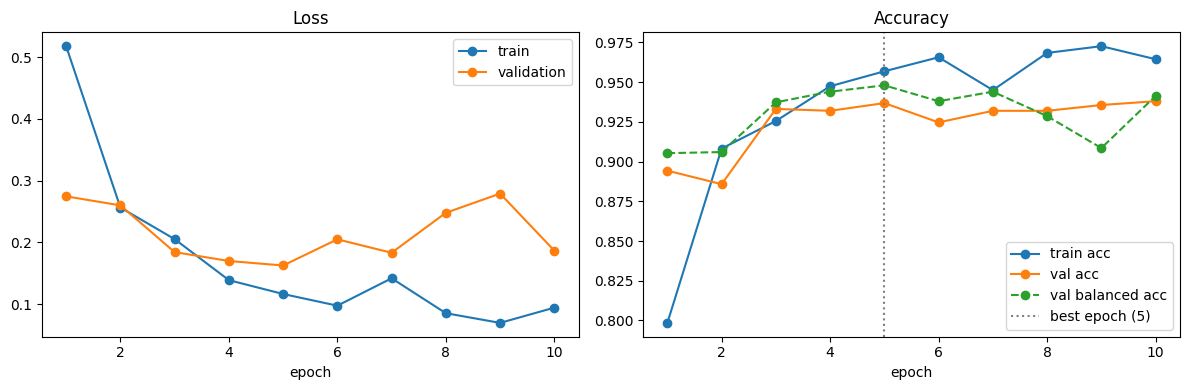

In [8]:
# ----------------------------
# Training curves
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df.epoch, history_df.train_loss, 'o-', label='train')
axes[0].plot(history_df.epoch, history_df.val_loss, 'o-', label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history_df.epoch, history_df.train_acc, 'o-', label='train acc')
axes[1].plot(history_df.epoch, history_df.val_acc, 'o-', label='val acc')
axes[1].plot(history_df.epoch, history_df.val_bal_acc, 'o--', label='val balanced acc')
axes[1].axvline(best_epoch, color='gray', linestyle=':', label=f'best epoch ({best_epoch})')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)
plt.show()

Validation accuracy:          93.68%
Validation balanced accuracy: 94.80%

              precision    recall  f1-score   support

   hamburger      0.929     0.915     0.922       200
     hot_dog      0.952     0.900     0.925       200
     dessert      0.910     0.960     0.934       200
       kebab      0.821     1.000     0.902        23
       pizza      0.975     0.965     0.970       200

    accuracy                          0.937       823
   macro avg      0.917     0.948     0.931       823
weighted avg      0.938     0.937     0.937       823



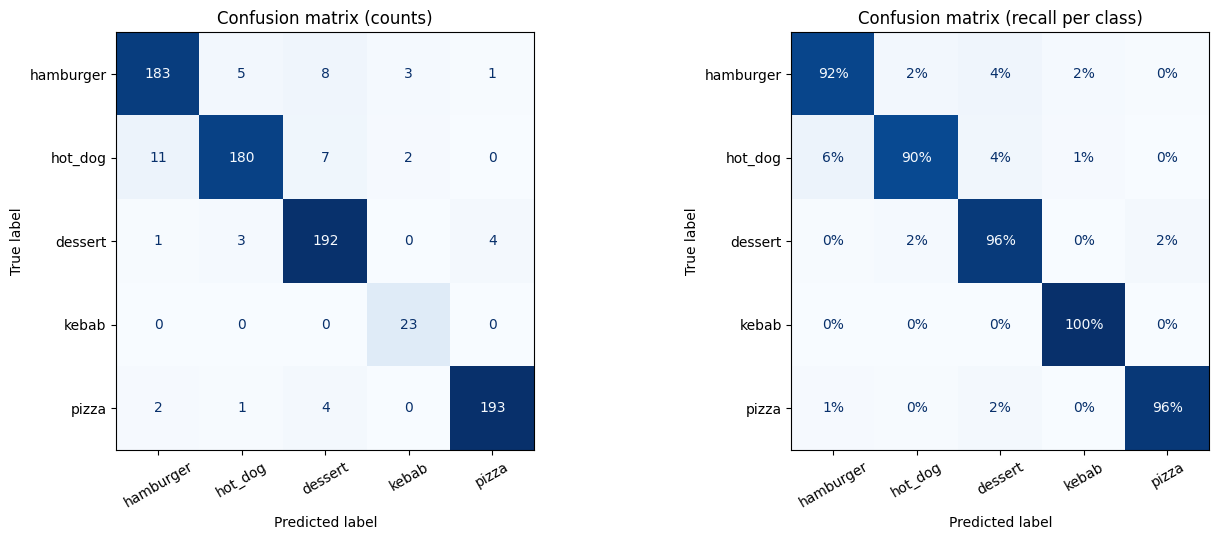

In [9]:
# ----------------------------
# Evaluation of the best model: confusion matrix + per-class report
# ----------------------------
model.load_state_dict(best_state)
_, y_true, y_pred = evaluate(model, val_loader)

print(f'Validation accuracy:          {accuracy_score(y_true, y_pred):.2%}')
print(f'Validation balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.2%}\n')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

report_df = pd.DataFrame(classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)).T
report_df.to_csv(f'{RESULTS_DIR}/classification_report.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix (counts)')
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, normalize='true'), display_labels=CLASSES).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.0%')
axes[1].set_title('Confusion matrix (recall per class)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrix.png', dpi=150)
plt.show()

/tmp/ipykernel_543/712459473.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 2), random_state=SEED)))


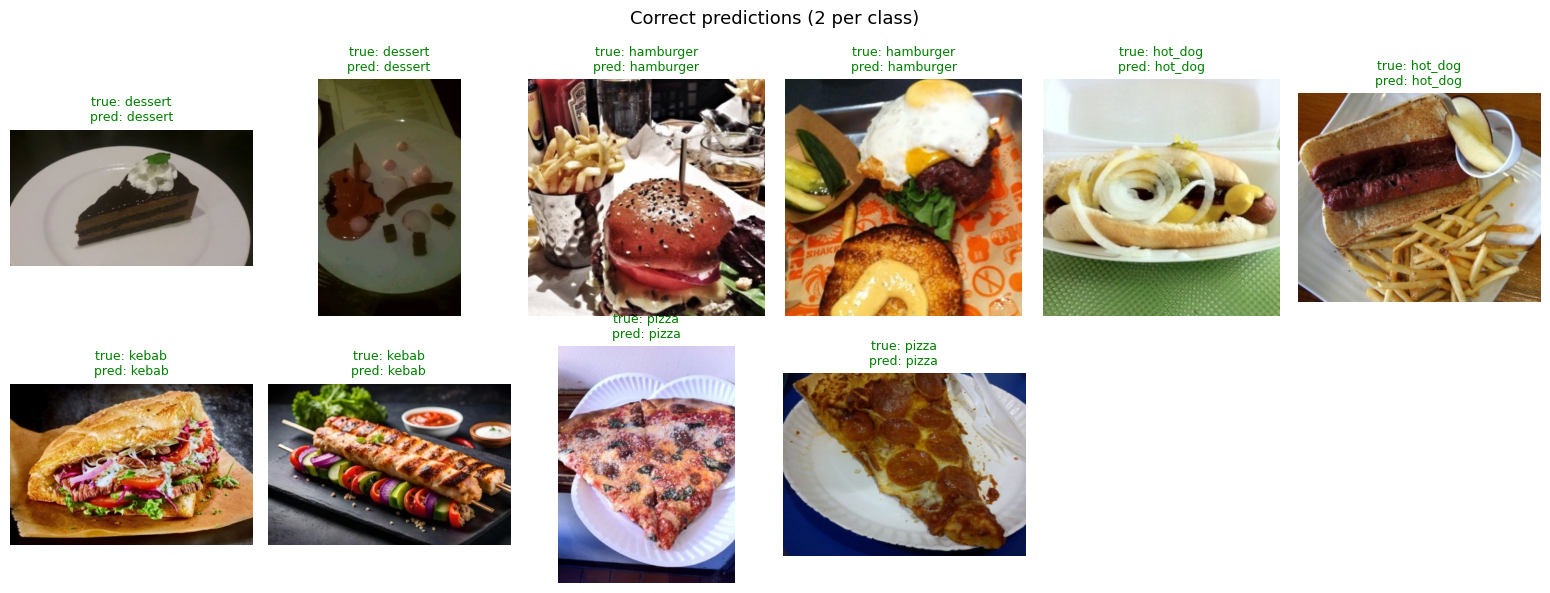

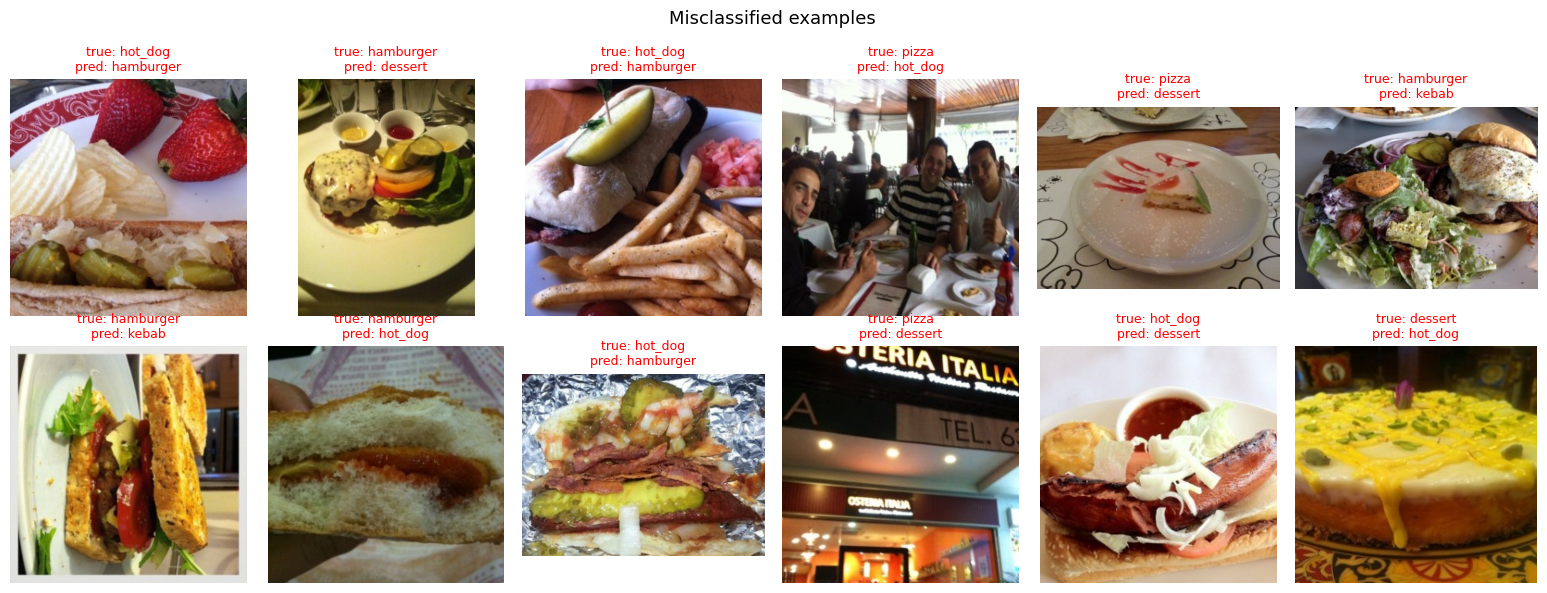

In [10]:
# ----------------------------
# Prediction gallery: correct and incorrect examples from validation
# ----------------------------
val_results = val_df.copy()
val_results['pred'] = [CLASSES[i] for i in y_pred]
val_results['correct'] = val_results['pred'] == val_results['class']


def show_gallery(frame, title, filename, cols=6):
    if len(frame) == 0:
        print(f'{title}: no images')
        return
    rows = (len(frame) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 3.0))
    for ax in np.array(axes).flat:
        ax.axis('off')
    for ax, (_, r) in zip(np.array(axes).flat, frame.iterrows()):
        ax.imshow(Image.open(r['path']))
        color = 'green' if r['correct'] else 'red'
        ax.set_title(f"true: {r['class']}\npred: {r['pred']}", fontsize=9, color=color)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/{filename}', dpi=150)
    plt.show()


correct_samples = (val_results[val_results.correct]
                   .groupby('class', group_keys=False)
                   .apply(lambda g: g.sample(min(len(g), 2), random_state=SEED)))
show_gallery(correct_samples, 'Correct predictions (2 per class)', 'predictions_correct.png')

wrong_samples = val_results[~val_results.correct].sample(
    min(12, (~val_results.correct).sum()), random_state=SEED)
show_gallery(wrong_samples, 'Misclassified examples', 'predictions_wrong.png')

Loaded model: best epoch 5, balanced accuracy 94.80%
Upload one or more food images (hamburger, hot dog, dessert, kebab, pizza):


Saving images (1).jpeg to images (1).jpeg


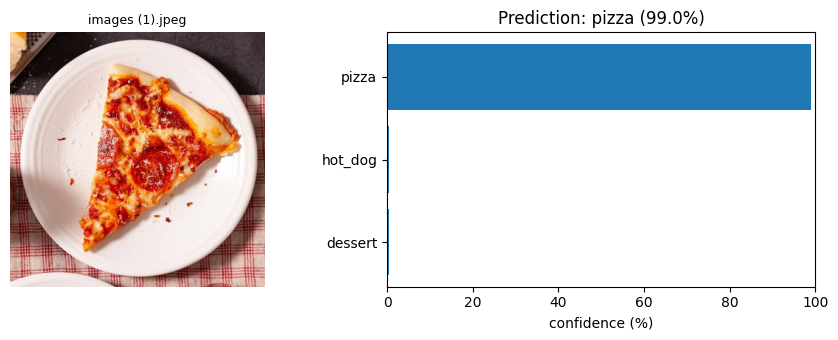

In [15]:
# ----------------------------
# Try it: upload your own food photos
# ----------------------------
from google.colab import files
import io

# weights_only=False: the checkpoint is our own file and also stores metadata (classes, epoch, score)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
infer_model = mobilenet_v2(weights=None)
infer_model.classifier[1] = nn.Linear(infer_model.classifier[1].in_features, len(checkpoint['classes']))
infer_model.load_state_dict(checkpoint['model_state'])
infer_model = infer_model.to(device).eval()
print(f"Loaded model: best epoch {checkpoint['epoch']}, balanced accuracy {float(checkpoint['val_bal_acc']):.2%}")

print('Upload one or more food images (hamburger, hot dog, dessert, kebab, pizza):')
uploaded = files.upload()

for name, data in uploaded.items():
    image = Image.open(io.BytesIO(data)).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(infer_model(eval_transform(image).unsqueeze(0).to(device)), dim=1)[0].cpu()
    top = torch.topk(probs, 3)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), gridspec_kw={'width_ratios': [1, 1.2]})
    axes[0].imshow(image); axes[0].axis('off'); axes[0].set_title(name, fontsize=9)
    labels = [checkpoint['classes'][i] for i in top.indices]
    axes[1].barh(labels[::-1], (top.values * 100).tolist()[::-1], color='tab:blue')
    axes[1].set_xlim(0, 100); axes[1].set_xlabel('confidence (%)')
    axes[1].set_title(f'Prediction: {labels[0]} ({top.values[0]:.1%})')
    plt.tight_layout()
    plt.show()